# LAB. De PDI - Leitura, Processamento Básico, Resoluções, Quantização




## Parte I: Manipulação de Imagens Digitais

### Carregar e Exibir Imagem em Tons de Cinza



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys

In [ ]:
# Baixa a imagem direto da URL(Sem precisar de upload manual toda vez que o colab reiniciar)
!wget -q -O monalisa.jpg https://upload.wikimedia.org/wikipedia/commons/b/b9/Mona_Lisa.PNG

In [ ]:
# Ler a imagem diretamente em escala de cinza
imagem = cv2.imread('monalisa.jpg', cv2.IMREAD_GRAYSCALE)

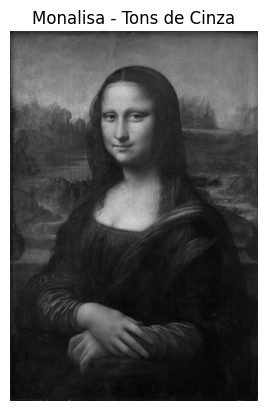

In [ ]:
# Tratamento de erro
if imagem is None:
  print("Erro ao carregar a imagem. Verifique o download ou o caminho.")
else:
  # Exibição da imagem
  plt.imshow(imagem, cmap='gray')
  plt.title('Monalisa - Tons de Cinza')
  plt.axis('off')
  plt.show()

In [ ]:
# Exibição da Imagem e Cálculos Dinâmicos
print("\n--- Informações da Imagem ---")
print(f"Shape (Resolução: Altura x Largura): {imagem.shape}")
print(f"Tipo de dado (Data type): {imagem.dtype}")

# Extraindo as dimensões reais da imagem armazenada na variável
altura, largura = imagem.shape

# Como é uma imagem de 8 bits (1 byte por pixel), o tamanho em byte é altura * largura
tamanho_calculado_kb = (altura * largura) / 1024

# Pegando o tamanho real que a matriz numpy está ocupando na memória RAM
tamanho_medido_kb = sys.getsizeof(imagem) / 1024

print(f"Tam. Calculado: {tamanho_calculado_kb:.2f} KB")
print(f"Tam. Medido: {tamanho_medido_kb:.2f} KB")


--- Informações da Imagem ---
Shape (Resolução: Altura x Largura): (3591, 2403)
Tipo de dado (Data type): uint8
Tam. Calculado: 8426.93 KB
Tam. Medido: 8427.05 KB


### **Perguntas de Reflexão:**

* O que significam os valores de intensidade dos pixels em uma imagem em tons de cinza?

  Em uma imagem em tons de cinza, os valores de intensidade dos pixels representam diretamente a quantidade de luz, ou luminância, capturada em cada ponto específico da cena. Nessa escala, o valor numérico zero corresponde à ausência total de luz, resultando no preto absoluto, enquanto o valor máximo representa a intensidade luminosa máxima, ou seja, o branco puro. Todos os valores numéricos intermediários formam as diferentes variações de tons de cinza que compõem os detalhes visuais da imagem, criando os contornos, as texturas e as sombras.

* Por que a imagem é representada em uint8? Como isso afeta a precisão e qualidade?

  A escolha do tipo de dado uint8, que significa um número inteiro sem sinal de 8 bits, ocorre porque essa arquitetura computacional permite armazenar exatamente 256 níveis diferentes de intensidade por pixel, variando de 0 a 255. O uso desse formato é o padrão ideal porque o olho humano possui uma limitação biológica e dificilmente consegue distinguir mais do que esses 256 tons simultaneamente em uma mesma imagem. Dessa forma, o formato uint8 garante uma transição suave de tons e uma percepção visual de excelente qualidade, ao mesmo tempo em que otimiza significativamente o espaço ocupado na memória RAM e no armazenamento do computador.

### Inversão (Negativo) de Imagem

In [ ]:
# 1. Criar o negativo da imagem (Operação vetorizada do NumPy)
negativo = 255 - imagem

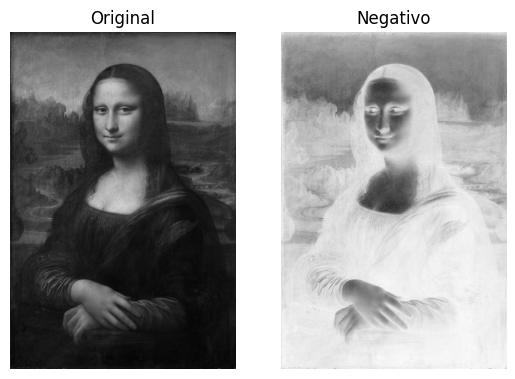

In [ ]:
# Configurando exibição lado a lado
# Cria uma figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2)

# Plotando a Original no primeiro quadro (índice 0)
axes[0].imshow(imagem, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Plotando o Negativo no segundo quadro (índice 1)
axes[1].imshow(negativo, cmap='gray')
axes[1].set_title('Negativo')
axes[1].axis('off')

# Exibe a imagem
plt.show()

### **Perguntas de Reflexão:**

* O que acontece com os valores dos pixels quando
criamos o negativo? Como isso altera a percepção
visual?

  Quando aplicamos a operação de inversão para criar o negativo de uma imagem, estamos matematicamente subtraindo o valor original de cada pixel da intensidade máxima permitida na nossa escala, que no caso de uma imagem de 8 bits é 255 (representado pela transformação *s* = 255 - *r* ). Na prática, isso significa que os pixels que originalmente possuíam valores baixos, ou seja, as áreas mais escuras, passam a ter valores altos e se tornam claros. Em contrapartida, as áreas inicialmente claras assumem valores baixos e escurecem, invertendo completamente a escala tonal da imagem. Essa transformação altera drasticamente a nossa percepção visual e é uma técnica muito útil para destacar detalhes anatômicos. O olho humano costuma ter dificuldade para identificar pequenas estruturas claras que estão perdidas em meio a fundos predominantemente escuros. Na área médica, como no exemplo das mamografias, criar o negativo da imagem faz com que lesões que estavam ofuscadas na imagem original se destaquem de forma muito mais nítida, facilitando a análise visual.

## Parte II: Quantização de Imagens

### Quantização com Diferentes Bits

In [ ]:
# Função matemática para quantização
def quantizar_imagem(img, bits):
  # Calcula o tamanho do "degrau" com base nos bits
  fator = 2 ** (8 - bits)
  # Divide (para agrupar os tons) e multiplica (para restaurar a escala de 0-255)
  img_quantizada = (img // fator) * fator
  return img_quantizada.astype('uint8')

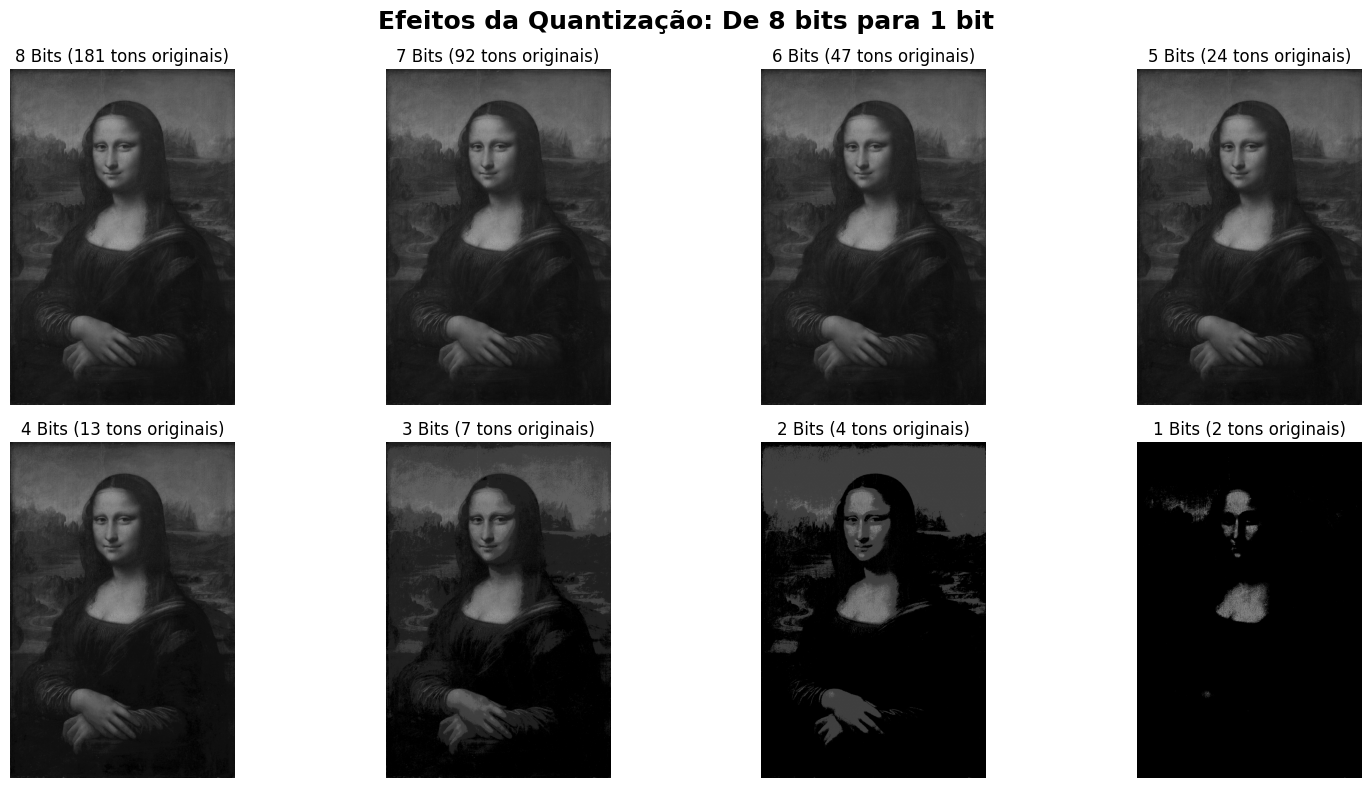

In [ ]:
# Configurar um grid de 2 linhas e 4 colunas
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Efeitos da Quantização: De 8 bits para 1 bit', fontsize=18, fontweight='bold')

# Lista de bits que o roteiro pediu para testar
niveis_bits = [8, 7, 6, 5, 4, 3, 2, 1]

# Laço de repetição para gerar e plotar as imagens de uma vez
for i, bits in enumerate(niveis_bits):
  # Calcula matematicamente em qual linha e coluna a imagem deve entrar
  linha = i // 4
  coluna = i % 4
  ax = axes[linha, coluna]

  # Aplica a função de quantização
  img_q = quantizar_imagem(imagem, bits)

  # Conta quantos tons de cinza realmente sobraram na matriz
  cores_unicas = len(np.unique(img_q))

  # Exibe a imagem travando a escala real de luz
  ax.imshow(img_q, cmap='gray', vmin=0, vmax=255)
  ax.set_title(f'{bits} Bits ({cores_unicas} tons originais)')
  ax.axis('off')

plt.tight_layout()
plt.show()


## **Perguntas de Reflexão:**

* Como a redução dos níveis de quantização impacta a qualidade visual?

  A redução dos níveis de quantização afeta diretamente a suavidade das transições de luz e sombra na imagem. O processo de quantização pode ser definido matematicamente pela fórmula $Q(r) = \left\lfloor \frac{r}{k} \right\rfloor \times k$ , onde diminuímos a quantidade de bits por pixel e, consequentemente, reduzimos o número total de tons de cinza disponíveis para representar a cena. O principal impacto visual dessa restrição matemática é o surgimento de um defeito conhecido como falso contorno. Em áreas da imagem que originalmente possuíam um gradiente suave, como o fundo de uma foto ou as sombras de um rosto, a falta de tons intermediários força a criação de blocos de cor sólida com bordas muito marcadas e artificiais, quebrando a ilusão de continuidade visual.

* Qual é o nível mínimo de bits em que a imagem ainda  ́é reconhecível sem muita perda de detalhes?

  Observando os resultados gerados e traçando um paralelo com a referência (Gonzalez), o nível mínimo de bits para que a imagem permaneça amplamente reconhecível e com uma qualidade visual aceitável costuma ficar em torno de cinco ou seis bits por pixel, o que equivale a 32 e 64 tons de cinza, respectivamente. Nesses níveis, um observador atento já começa a perceber sutis falsos contornos nas áreas de transição mais suave, mas as texturas e as estruturas anatômicas principais da imagem ainda estão perfeitamente preservadas. Quando descemos para quatro bits ou menos, a perda de informação tonal se torna muito severa, fazendo com que a imagem adquira um aspecto chapado e artificial de baixíssima resolução, prejudicando drasticamente a identificação de detalhes finos e o reconhecimento imediato de feições complexas.

## Parte III: Compressão e Qualidade Visual

### Comparar Compressão JPEG

In [ ]:
import os

# Salvar as versões comprimidas no disco usando o codificador JPEG do OpenCV
cv2.imwrite('img_jpeg_95.jpg', imagem, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
cv2.imwrite('img_jpeg_50.jpg', imagem, [int(cv2.IMWRITE_JPEG_QUALITY), 50])

True

In [ ]:
# Obter o tamanho dos arquivos em disco (em KB)
tam_original = imagem.nbytes / 1024 # Tamanho real da matriz na memória RAM
tam_95 = os.path.getsize('img_jpeg_95.jpg') / 1024
tam_50 = os.path.getsize('img_jpeg_50.jpg') / 1024


In [ ]:
# Carregar as imagens recém-comprimidas de volta para o Python
img_95 = cv2.imread('img_jpeg_95.jpg', cv2.IMREAD_GRAYSCALE)
img_50 = cv2.imread('img_jpeg_50.jpg', cv2.IMREAD_GRAYSCALE)

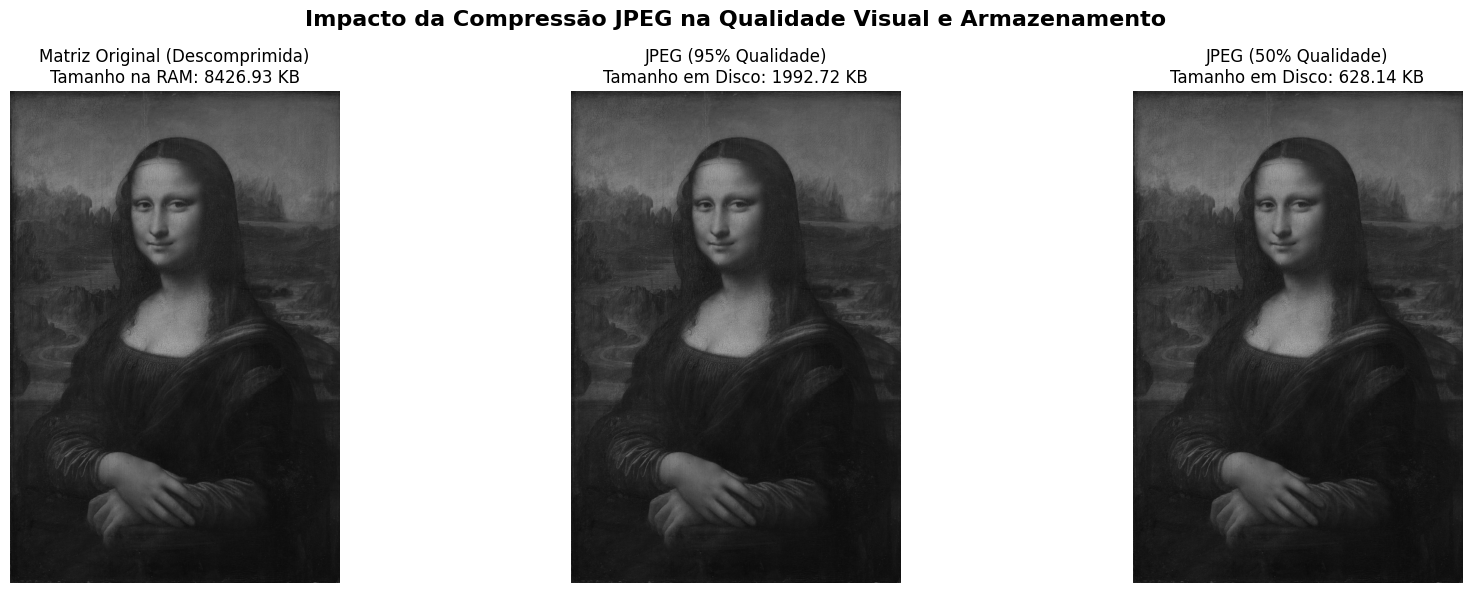

In [ ]:
# Configurar a exibição lado a lado (1 linha 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Impacto da Compressão JPEG na Qualidade Visual e Armazenamento', fontsize=16, fontweight='bold')

# Plot: Original
axes[0].imshow(imagem, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Matriz Original (Descomprimida)\nTamanho na RAM: {tam_original:.2f} KB')
axes[0].axis('off')

# Plot: JPEG 95%
axes[1].imshow(img_95, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'JPEG (95% Qualidade)\nTamanho em Disco: {tam_95:.2f} KB')
axes[1].axis('off')

# Plot: JPEG 50%
axes[2].imshow(img_50, cmap='gray', vmin=0, vmax=255)
axes[2].set_title(f'JPEG (50% Qualidade)\nTamanho em Disco: {tam_50:.2f} KB')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### **Perguntas de Reflexão**

* Como a compressão JPEG afeta a qualidade visual? Quais detalhes são mais afetados?

  A compressão JPEG é um algoritmo com perdas que afeta a qualidade visual ao focar em descartar as informações de alta frequência da imagem, baseando-se no fato de que o olho humano é menos sensível a variações rápidas de intensidade e mais sensível ao brilho geral. O algoritmo divide a imagem em blocos e aplica a Transformada Discreta de Cosseno. Ao forçar uma taxa de compressão mais agressiva, como o nível de 50%, os detalhes mais afetados são as bordas nítidas, as texturas finas e as áreas de transição de contraste. Visualmente, isso resulta no conhecido "efeito de bloco" (onde os quadrados do processamento se tornam visíveis a olho nu), além do borramento ao redor dos contornos detalhados e da perda de suavidade em gradientes contínuos.

* A qualidade de compressão a 50% ainda é aceitável? Em que situações pode ser usada?

  A aceitabilidade de uma compressão JPEG a 50% depende exclusivamente do domínio de aplicação da imagem. Do ponto de vista semântico, a qualidade ainda é aceitável para o reconhecimento do conteúdo principal da cena, sendo extremamente útil em situações onde a economia de armazenamento e de banda de rede é a prioridade crítica. Exemplos de uso incluem a transmissão rápida de dados em ambientes IoT ou geração de miniaturas para a web. No entanto, essa taxa de compressão é totalmente inaceitável para áreas que exigem preservação rigorosa de detalhes morfológicos e alta frequência, como diagnósticos em imagens médicas, sistemas de visão computacional de precisão e reconhecimento facial, pois os artefatos gerados pelo algoritmo podem ser interpretados erroneamente como estruturas físicas reais.

## Parte IV: Resolução de Intensidade e Espacial

### Reduzir a Resolução de Intensidade

In [ ]:
def reduzir_intensidade(img, niveis):
  # Calcula o tamanho do "degrau" (Para 16 níveis, o fator será 16)
  fator = 256 // niveis

  # Divide para agrupar e multiplica de volta (exatamente como na quantização)
  img_reduzida = (img // fator) * fator

  return img_reduzida.astype('uint8')

In [ ]:
# Gerar a imagem com apenas 16 níveis
img_16_niveis = reduzir_intensidade(imagem, 16)

In [ ]:
# Calcula os tons reais de ambas as imagens
tons_originais = len(np.unique(imagem))
tons_reduzidos = len(np.unique(img_16_niveis))

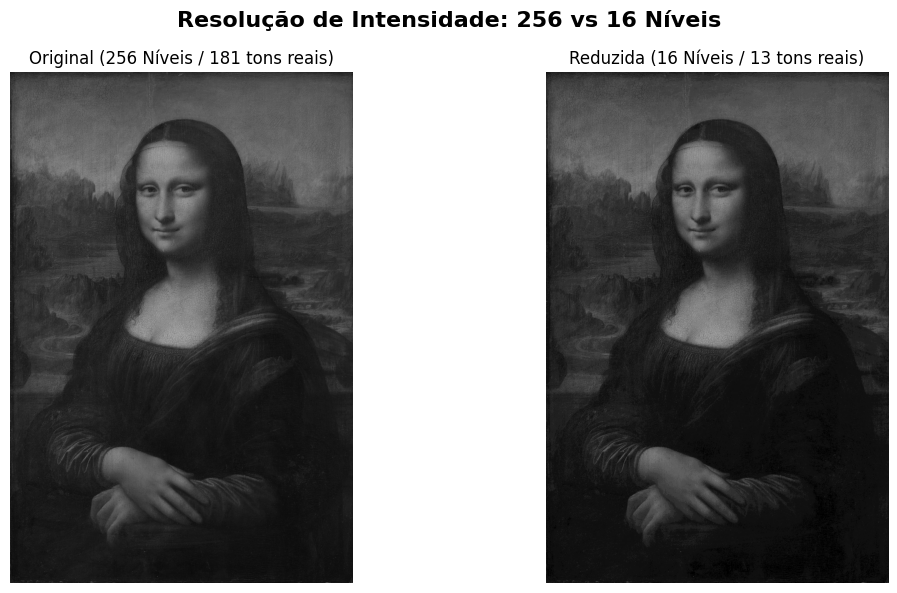

In [ ]:
# Configurar a exibição lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Resolução de Intensidade: 256 vs 16 Níveis', fontsize='16', fontweight='bold')

axes[0].imshow(imagem, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Original (256 Níveis / {tons_originais} tons reais)')
axes[0].axis('off')

axes[1].imshow(img_16_niveis, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Reduzida (16 Níveis / {tons_reduzidos} tons reais)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### **Perguntas de Reflexão:**

* Qual é o impacto da redução de níveis de intensidade na suavidade dos gradientes?

  O impacto direto da redução dos níveis de intensidade é a quebra da suavidade tonal contínua, resultando no falso contorno. Matematicamente, a resolução de intensidade dita o quão finos são os "degraus" de transição entre a luz e a sombra. Quando reduzimos a imagem de 256 níveis para apenas 16 níveis, estamos forçando áreas de gradiente suave (que possuíam dezenas de tons intermediários) a se aglutinarem em um único valor constante. Visualmente, o gradiente desaparece e dá lugar a blocos sólidos de cor com fronteiras rígidas e artificiais, que degradam severamente a percepção de volume e profundidade da cena.

* Qual a importância de manter alta resolução de intensidade em imagens médicas?

  Em imagens médicas, como radiografias, tomografias ou mamografias, a manutenção de uma alta resolução de intensidade é crítica para evitar erros de diagnóstico. O corpo humano apresenta tecidos com densidades radiológicas extremamente semelhantes. Um tumor em estágio inicial ou uma microcalcificação pode diferir do tecido saudável vizinho por apenas duas ou três unidades de intensidade na escala de cinza. Se a resolução de intensidade for baixa, esses poucos níveis de diferença são quantizados e agrupados dentro do mesmo degrau do tecido saudável, fazendo com que a patologia desapareça completamente da tela e se torne invisível aos olhos do médico radiologista.

* O que é intervalo dinâmico ou dynamic range?

  O intervalo dinâmico, ou dynamic range, é definido como a relação matemática entre a máxima intensidade luminosa que um sistema consegue registrar de forma confiável (sem saturar) e a mínima intensidade detectável (onde o sinal supera o ruído inerente do sensor). No contexto estrito da imagem digital, ele determina o espectro total de tons que podem ser exibidos simultaneamente. Em uma imagem padrão de 8 bits, o intervalo dinâmico abrange 256 níveis discretos, variando do preto absoluto (valor 0) até o branco puro (valor 255). Um alto intervalo dinâmico garante que uma imagem consiga reter detalhes finos nas áreas de sombra profunda ao mesmo tempo em que preserva as texturas nas áreas de alta luminosidade.

### Reduzir a Resolução Espacial

In [ ]:
# Função para simular a redução de resolução espacial
def reduzir_resolucao_espacial(img, fator):
  altura, largura = imagem.shape

  # Primeiro passo: Subamostragem (encolhe a imagem jogando dados reais fora)
  nova_largura = largura // fator
  nova_altura = altura // fator
  img_encolhida = cv2.resize(img, (nova_largura, nova_altura), interpolation=cv2.INTER_AREA)

  # Segundo passo: Reconstrução visual (estica de volta, preservando os "blocos" para podermos enxergar)
  img_pixelizada = cv2.resize(img_encolhida, (largura, altura), interpolation=cv2.INTER_NEAREST)

  return img_pixelizada, (nova_largura, nova_altura)



In [ ]:
# Aplicar a redução (fator 4 significa reduzir a área total em 16 vezes)
fator_reducao = 4
img_reduzida_espacial, dimensoes_reais = reduzir_resolucao_espacial(imagem, fator_reducao)

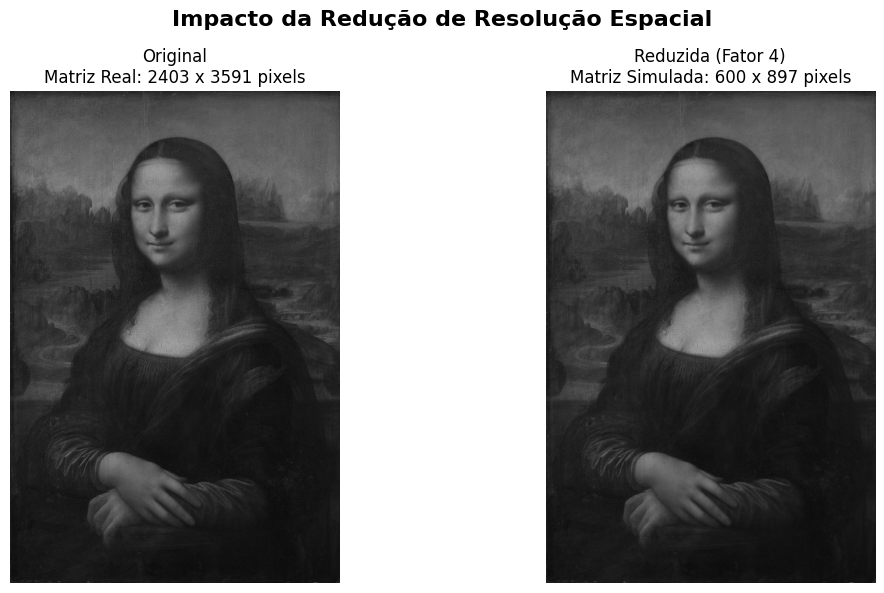

In [ ]:
# Configurar a exibição
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Impacto da Redução de Resolução Espacial', fontsize=16, fontweight='bold')

axes[0].imshow(imagem, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Original\nMatriz Real: {imagem.shape[1]} x {imagem.shape[0]} pixels')
axes[0].axis('off')

axes[1].imshow(img_reduzida_espacial, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Reduzida (Fator {fator_reducao})\nMatriz Simulada: {dimensoes_reais[0]} x {dimensoes_reais[1]} pixels')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### **Perguntas de Reflexão:**

* Como a redução da resolução espacial afeta a capacidade de identificar detalhes?

  A redução da resolução espacial afeta a identificação de detalhes ao eliminar os componentes de alta frequência da imagem, como texturas finas, bordas nítidas e pequenos objetos. Matematicamente, isso ocorre através da subamostragem. Se uma estrutura anatômica ou um objeto na cena real for geometricamente menor do que a área de cobertura de um uníco pixel na matriz reduzida, esse detalhe se fundirá com a cor do fundo e desaparecerá completamente. Visualmente, a perda de resolução geométrica gera o efeito de pixelização, transformando curvas suaves e linhas diagonais em padrões quadriculados que destroem a morfologia do objeto analisado.

* Qual seria a resolução mínima aceitável para diagnósticos médicos ou impressão?

  A resolução espacial mínima exigida depende estritamente da criticidade da aplicação. Para materiais gráficos e impressões comerciais, o padrão histórico mínimo estabelecido é de 300 DPI, o que garante que os "blocos" sejam pequenos o suficiente para enganar o sistema visual humano a uma distância normal de leitura, criando a ilusão de um traço contínuo. Já no diagnóstico médico, as restrições são severamente regulamentadas, pois a vida do paciente depende da geometria dos pixels. Uma mamografia digital, por exemplo, exige detectores de alta resolução com tamanho de pixel na ordem de 50 micrômetros (o que equivale a mais de 500 DPI). Essa densidade extrema é a resolução mínima inegociável para garantir que microcalcificações patológicas, principais indicadores de anomalias, não sejam perdidas na "malha" dos pixels do sensor.


## Parte V: Conectividade e Adjacência

### Conectividade 4 e 8

In [ ]:
# Binarização da Imagem (Thresholding)
# Tudo que for mais escuro que 128 vira preto (0 - fundo), o resto vira branco (255 - objeto)
_, img_binaria = cv2.threshold(imagem, 128, 255, cv2.THRESH_BINARY)

In [ ]:
# Algoritmo de Componentes Conectados
# A função retorna o número de objetos encontrados e uma matriz onde cada pixel recebe o "ID" do seu grupo
num_labels_4, labels_4 = cv2.connectedComponents(img_binaria, connectivity=4)
num_labels_8, labels_8 = cv2.connectedComponents(img_binaria, connectivity=8)

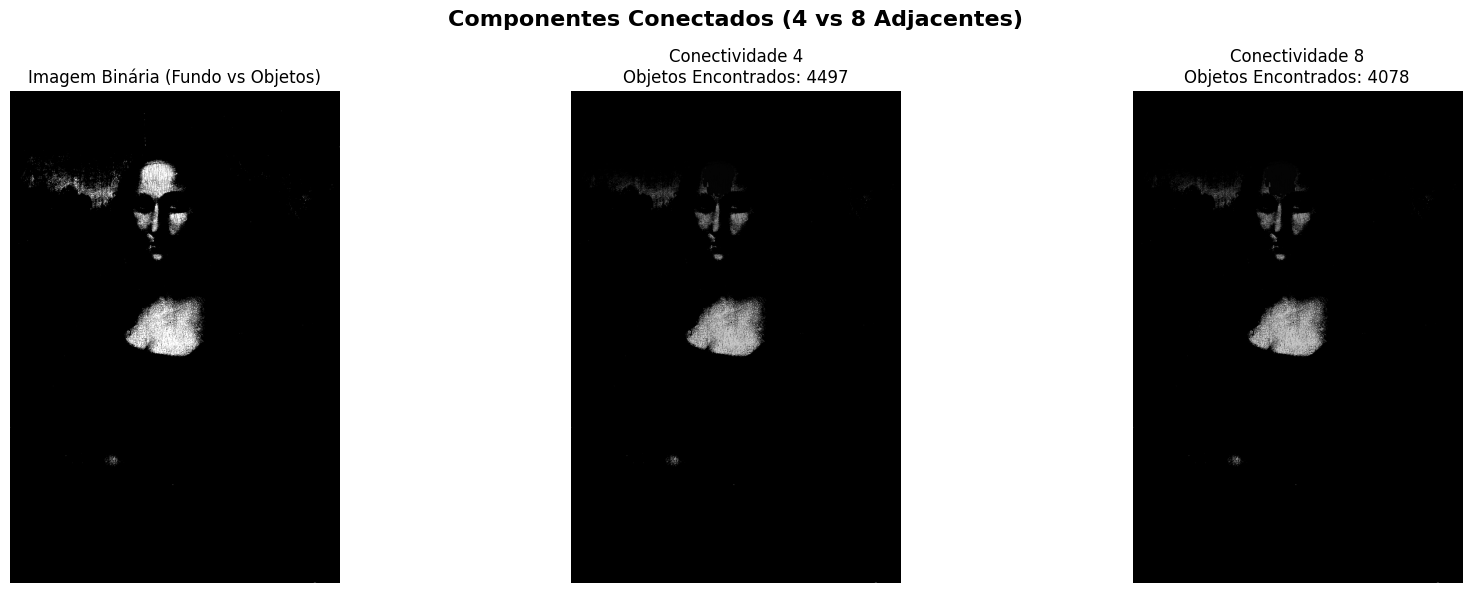

In [ ]:
# Configurar a plotagem
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Componentes Conectados (4 vs 8 Adjacentes)', fontsize=16, fontweight='bold')

# Plot da Binária
axes[0].imshow(img_binaria, cmap='gray')
axes[0].set_title('Imagem Binária (Fundo vs Objetos)')
axes[0].axis('off')

# Plot Conectividade 4
axes[1].imshow(labels_4, cmap='gray')
axes[1].set_title(f'Conectividade 4\nObjetos Encontrados: {num_labels_4 - 1}')
axes[1].axis('off')

# Plot Conectividade 8
axes[2].imshow(labels_8, cmap='gray')
axes[2].set_title(f'Conectividade 8\nObjetos Encontrados: {num_labels_8 -1}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### **Conceitos a Pesquisar:**

* O que é conectividade 4-adjacente e 8-adjacente?

  A conectividade define a regra matemática de vizinhança entre os pixels. Na 4-adjacência $N_4(p)$ , um pixel central só é considerado conectado aos seus vizinhos diretos que compartilham uma aresta inteira (acima, abaixo, à esquerda, e à direita). Na 8-adjacência $N_8(p)$ , a regra é expandida para incluir também os quatro vizinhos diagonais que compartilham apenas um vértice (quinas) com o pixel central.

* Como identificar componentes conectados em imagens binárias?

  A identificação é feita através de algoritmos de varredura (como o Flood-Fill ou o algoritmo de Duas Passagens). O sistema percorre a matriz de pixels buscando valores ativos (brancos). Ao encontrar um pixel ativo, ele verifica os seus vizinhos de acordo com a conectividade escolhida (4 ou 8). Se um vizinho também for ativo, ele recebe o mesmo "rótulo" (ID). O processo se repete recursivamente até que todos os pixels conectados formem um único "blob" ou componente, permitindo a contagem e e isolamento de elementos distintos na imagem.

* Qual a diferença prática entre usar conectividade
4 vs 8?

  A diferença prática reside na forma como o algoritmo interpreta o limite físico dos objetos na malha de pixels. A conectividade 4 é mais estrita e "conservadora": como ela ignora as diagonais, qualquer afinamento ou curva em um objeto digitalizado que deixe os pixels conectados apenas pelas quinas fará com que o algoritmo considere que o objeto foi rompido naquele ponto. Já a conectividade 8 é mais "permissiva" e robusta a falhas de digitalização: ao reconhecer as quinas, ela consegue manter a integridade estrutural de linhas finas, bordas serrilhadas e formas complexas, rastreando o objeto contínuo mesmo onde ele parece quase quebrado na matriz.

### Importância da Conectividade

### **Perguntas de Reflexão:**

* Por que a conectividade é fundamental em análise
de imagens médicas?

  A conectividade é o pilar matemático da segmentação e do diagnóstico auxiliado por computador. Em uma imagem médica (como uma ressonância magnética), um órgão ou um tumor é apenas um agrupamento de pixels com intensidades parecidas. Os algoritmos de conectividade permitem que o software isole uma massa tumoral do tecido saudável vizinho, calcule a sua área exata (somando os pixels conectados) ou realize a contagem automatizada de células em uma amostra de sangue. Sem a análise de adjacência, o computador enxergaria apenas uma nuvem de pontos isolados, sendo incapaz de identificar entidades anatômicas.

* Como a escolha entre conectividade 4 ou 8 afeta
a contagem de objetos?

  Como demonstrado na prática pelo algoritmo, a escolha dita o rigor da união estrutural. A conectividade 4, por não reconhecer vértices diagonais, rompe facilmente com bordas curvas, linhas finas ou serrilhados, dividindo um único elemento físico em várias partes e resultando em um exagero significativo na contagem. Já a conectividade 8 age como um consolidador, unindo pixels que se tocam apenas pelas quinas. Isso preserva a integridade de formas complexas, resultando em uma contagem muito menor e, na maioria dos casos reais, muito mais fiel à quantidade real de objetos presentes na cena.

* Quais aplicações práticas usam análise de conectividade?

  Além da área da saúde, a análise de conectividade é muito utilizada em:
  * Robótica e Navegação Autônoma: Essencial para que os robôs processem o mapa do ambiente, agrupando pixels para identificar obstáculos contínuos (como paredes ou objetos no caminho) e planejar rotas seguras de desvio.

  * Sistemas OCR (Reconhecimento Ótico de Caracteres): Usada para isolar e extrair cada letra ou número de um documento escaneado ou placa de trânsito antes de passá-los para a rede neural.

  * Inspeção de Qualidade Industrial: Empregada na verificação de placas de circuito impresso (PCBs) para garantir que as trilhas de cobre estão perfeitamente conectadas e identificar microfissuras.


## Parte VI: Impacto dos Sensores na Qualidade

### Adicionar Ruído para Simular Sensores de Baixa Qualidade

In [28]:
# Geração de Ruído Gaussiano
# Média (0) e Desvio Padrão (30) definem a intensidade da granulação
ruido_gaussiano = np.random.normal(0, 30, imagem.shape)

In [29]:
# Injeção do ruído na matriz original
# O clip garante que a soma não passe 255 nem fique abaixo de 0
img_com_ruido = np.clip(imagem + ruido_gaussiano, 0, 255).astype('uint8')

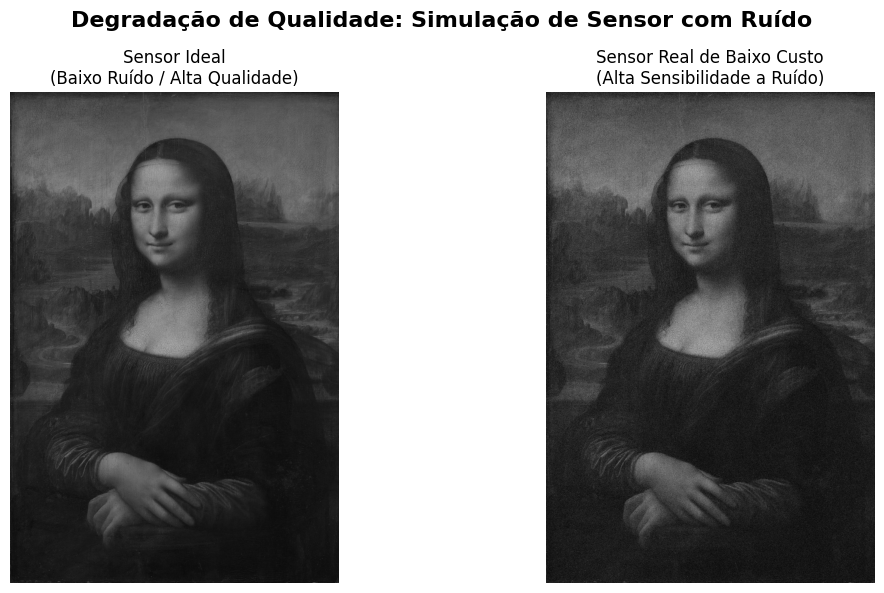

In [31]:
# Configurar exibição
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Degradação de Qualidade: Simulação de Sensor com Ruído', fontsize=16, fontweight='bold')

axes[0].imshow(imagem, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Sensor Ideal\n(Baixo Ruído / Alta Qualidade)')
axes[0].axis('off')

axes[1].imshow(img_com_ruido, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Sensor Real de Baixo Custo\n(Alta Sensibilidade a Ruído)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### **Perguntas de Reflexão:**

* Como o ruído de sensores de baixa qualidade afeta
a clareza da imagem?

  O ruído afeta a clareza ao introduzir variações aleatórias na intensidade dos pixels, o que degrada diretamente a Relação Sinal-Ruído (SNR) da captura. Matematicamente, o ruído Gaussiano simulado se sobrepõe aos componentes de alta frequência da imagem real. Visualmente, isso cria um aspecto granulado que mascara texturas finas e destrói a nitidez das bordas. Essa degradação dificulta severamente as etapas posteriores de Visão Computacional, pois algoritmos de segmentação e limiarização passam a ter dificuldade para distinguir se uma transição de tom é uma borda real de um objeto ou apenas uma flutuação aleatória gerada pela imperfeição do sensor.

* Quais medidas podem mitigar os efeitos de ruído
em imagens capturadas?

  A mitigação do ruído pode ser atacada em duas frentes distintas:

  * No Hardware (Captura): Utilizar sensores de melhor qualidade física (fotodiodos maiores que captam mais fótons), aumentar o tempo de exposição da câmera para absorver mais luz real (melhorando o SNR), reforçar a iluminação do ambiente ou utilizar sistemas de resfriamento no sensor para diminuir a agitação térmica dos elétrons (ruído térmico).

  * No Software (Pós-processamento de PDI): A aplicação de filtros espaciais. Filtros de suavização lineares, como o Filtro da Média ou o Filtro Gaussiano, podem ser convoluídos sobre a matriz para borrar levemente a imagem e diluir  a granulação aleatória. Para preservar as bordas enquanto remove o ruído, filtros não-lineares, como o Filtro da Mediana, são alternativas computacionais extremamente eficazes.
